# Data Visualization in Python

## Research Computing Services

Instructor: Scott Ladenheim, PhD <br>
Website: [rcs.bu.edu](http://www.bu.edu/tech/support/research/) <br>
Tutorial materials: [http://rcs.bu.edu/examples/python/DataVisualization](http://rcs.bu.edu/examples/python/DataVisualization) <br>
Contact us: help@scc.bu.edu

## Data visualization software

Data visualization software is a tool you use to you relay information about data. There are many data visualization software packages available. Today I will present how to use a few of these pacakges. The focus is on how to use them on the SCC. However, what I demonstrate in the tutorial should be applicable on other systems. By the end of the tutorial you will understand:

- how to create plots in Matplotlib, Seaborn, Pandas plot, and Plotly,
- how to adjust plot properties, e.g., color schemes, titles, axis labels, marker sizes, ect.,
- where to find documentation when you don't know what to do or where to start.

### Matplotlib

Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python.

https://matplotlib.org/

### Seaborn

Seaborn is a Python data visualization library built on top of matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics. Closely integrated to work with dataframes.

https://seaborn.pydata.org/

### Pandas plot

Data visualization routines within Pandas that allow you to easily plot the data within a dataframe.

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html


### Plotly

Plotly's Python graphing library makes interactive, publication-quality graphs. Plotly is open-source and free to use. Plotly works with R, Julia, Javascript and Matlab. 

https://plotly.com/python/

## Matplotlib

API reference page for the latest stable version of matploblib: 

https://matplotlib.org/stable/api/index

### Matplotlib backends

In [ ]:
# Import matplotlib with name mpl
import matplotlib as mpl

#### Interactive plots in Jupyter notebook

In [ ]:
# The %matplotlib magic function is a feature of the IPython interpreter that Jupyter Notebooks use.
# This is NOT A PYTHON COMMAND. Don't use this in a plain Python file.
# This tells matplotlib to use an interactive plot window inside the Notebook.

# If you are running JupyterLab DON'T run this line. Run the cell with the $matplotlib widget call.
%matplotlib notebook

In [ ]:
# You could alternatively set the interactive plot window using regular Python:
# mpl.use('nbAgg')

In [ ]:
mpl.get_backend()

In [ ]:
# Here's a list of all of the available backends
mpl.rcsetup.all_backends

#### Interactive plots in JupyterLab
If you are using JupyterLab you need to install the ipympl library https://github.com/matplotlib/ipympl and can then use the command

`%matploblib widget`

In [ ]:
# Uncomment the line below and run this cell if you use Jupyterlab 
# %matplotlib widget

### Using Backends

In general, you don't have to worry about setting of the backend. You can always let matplotlib choose the default for your computer. In a Jupyter notebook (or JupyterLab) the command `%matplotlib notebook` (`%matplotlib widget`) can be used, as we do here.

If you are running a Python program that will create plots using matplotlib it will try to open a graphics window by default. If you don't want that to happen, for instance you're running a batch job on the SCC where graphics aren't available, use the 'agg' backend. This allows for plots to be created in memory and then saved to disk. The backend must be set before calling any matplotlib functions.

For example, in a Python program running as a batch job on the SCC:

```
import matplotlib as mpl
mpl.use('agg')
import matplotlib.pyplot as plt
#...do stuff and make plots...
```

### Turning off interactive

You can alternatively turn off the interactive mode using `%matplotlib inline`.

In [ ]:
# Uncomment the below line to set interactive mode off
#%matplotlib inline

### Scripting and object oriented interface layers

There are two main ways to interact with matplotlib to create your graphs. In this tutorial I try work with them seperately as much as possible. However they can, and often are (especially on sites like stackoverflow), used in tandem. It is important to understand the difference between the two layers and how they are used. The two interface layers are:

- scripting,
- object oriented.

Let's see how they work with some example plots below.

In [1]:
# Import the matplotlib submodule pyplot
import matplotlib.pyplot as plt

#### Scripting interface

We plot the function f(x) = sin(x). The scripting interface makes function calls to create and modify the plot.  When the scripting layer is used, pyplot has a notion of a current figure and a current axes which all the functions you call act on.

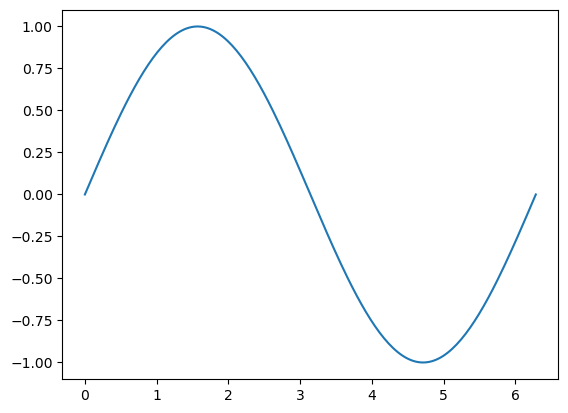

In [2]:
import numpy as np

x = np.linspace(0, 2 * np.pi, 200)
y = np.sin(x)

### Using the scripting API via plt
plt.figure()
plt.plot(x, y)
plt.show()

#### Object oriented layer

Plotting the same function using the object oriented layer. The function call to subplots() returns two objects:

- a figure object, `fig`,
- an axis object, `ax`.

We then use the properties and functions of these objects to create the plot. The object oriented layer is useful for fine grain control of the plot.

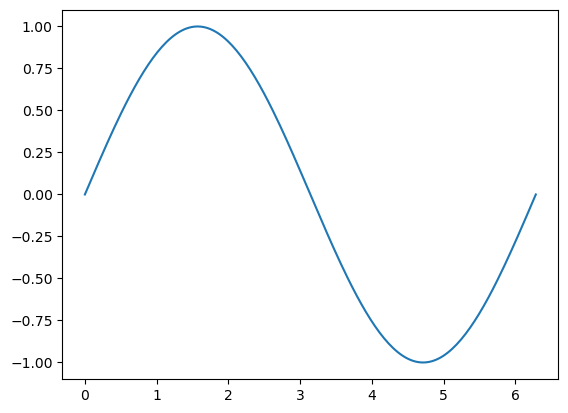

In [3]:
### Using the object oriented API
fig, ax = plt.subplots()
ax.plot(x, y)
plt.show()

#### The Figure and Axes objects

Figure is the top-level object that holds all plot elements (see https://matplotlib.org/stable/api/figure_api.html#matplotlib.figure.Figure for more details). With this object you can set properties such as 

- figsize
- dpi (dots per inch)
- layout

Axes is an object that encapsulates all the elements of an individual (sub-) plot in a figure (see https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.html#matplotlib.axes.Axes for more details). With this object you can set properties such as:

- xlim, ylim
- xlabel, ylabel
- legend
- title
- linewidth
- fontsizes


### Changing the plotting style

Online visual guide here:

https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html

More informantion on color palettes here:

https://seaborn.pydata.org/tutorial/color_palettes.html

In [4]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [5]:
plt.style.use('seaborn-v0_8-colorblind')

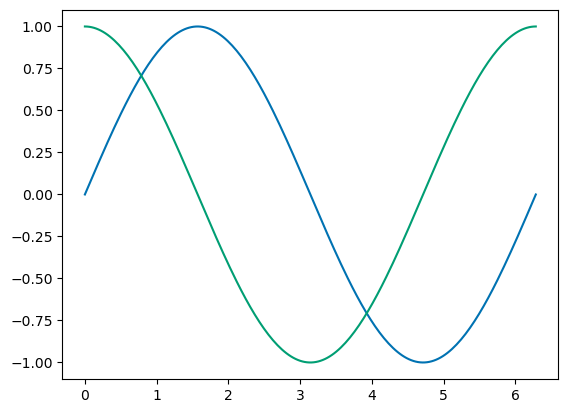

In [6]:
### Using the scripting API via plt
y2 = np.cos(x)

plt.figure()
plt.plot(x, y, x, y2)
plt.show()

In [7]:
# Ask for help on the plot function. This is a notebook-only syntax:
plt.plot?
# in a plain Python console we'd use (it will also work here):
# help(plt.plot)

Signature:
plt.plot(
    *args: 'float | ArrayLike | str',
    scalex: 'bool' = True,
    scaley: 'bool' = True,
    data=None,
    **kwargs,
) -> 'list[Line2D]'
Docstring:
Plot y versus x as lines and/or markers.

Call signatures::

    plot([x], y, [fmt], *, data=None, **kwargs)
    plot([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)

The coordinates of the points or line nodes are given by *x*, *y*.

The optional parameter *fmt* is a convenient way for defining basic
formatting like color, marker and linestyle. It's a shortcut string
notation described in the *Notes* section below.

>>> plot(x, y)        # plot x and y using default line style and color
>>> plot(x, y, 'bo')  # plot x and y using blue circle markers
>>> plot(y)           # plot y using x as index array 0..N-1
>>> plot(y, 'r+')     # ditto, but with red plusses

You can use `.Line2D` properties as keyword arguments for more
control on the appearance. Line properties and *fmt* can be mixed.
The following two calls yie

### Saving a figure

In [8]:
# Scripting layer you would call. Observe that this saves the last open interactive window.
plt.savefig('sine_cosine-sl.pdf')

<Figure size 640x480 with 0 Axes>

In [9]:
# Object oriented layer call. Observe that this saves the object stored in the fig object.
fig.savefig('sine-ool.pdf');

You can save a figure in the following formats:

- '.png'
- '.jpg'
- '.svg'

There are many more parameters you can pass to savefig, for example dpi, format, etc. Documenationa for savefig is here: 

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html.

### Modify a plot

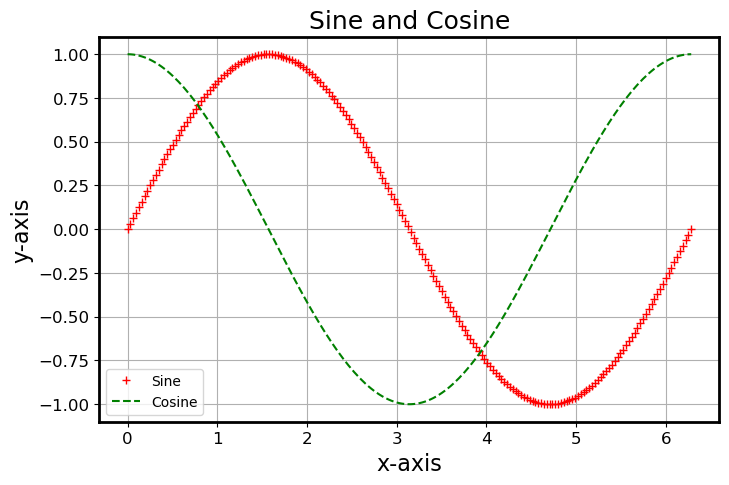

In [10]:
# Scripting level api

plt.figure(figsize=(8, 5))
plt.plot(x, y, 'r+', x, y2, 'g--')
plt.xlabel('x-axis', fontsize=16)
plt.ylabel('y-axis', fontsize=16)
plt.title("Sine and Cosine", fontsize=18)
plt.legend(['Sine', 'Cosine'])
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
axes = plt.gca()
axes.spines[['top', 'bottom', 'left', 'right']].set_linewidth(2)
plt.grid()
plt.show()

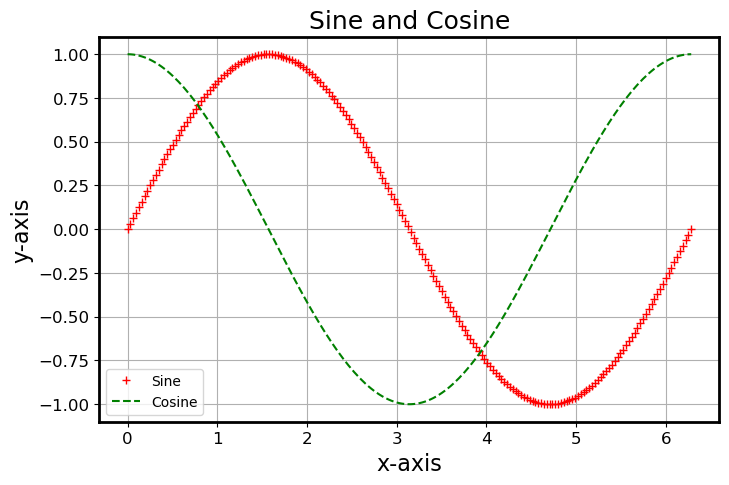

In [11]:
# Plot the same line with OO layer

fig1, ax1 = plt.subplots()
fig1.set_size_inches(8, 5)
ax1.plot(x, y, 'r+', x, y2, 'g--')
ax1.set_xlabel('x-axis', fontsize=16)
ax1.set_ylabel('y-axis', fontsize=16)
ax1.set_title("Sine and Cosine", fontsize=18)
ax1.legend(['Sine', 'Cosine'])
ax1.spines[['top', 'bottom', 'left', 'right']].set_linewidth(2)
ax1.tick_params(axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.grid()
plt.show()

## Other plot options can be found here https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

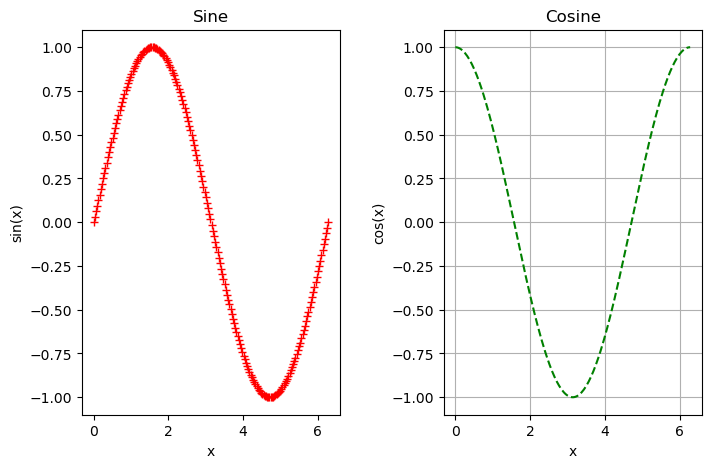

In [12]:
# Make a subplot with 1 row and 2 columns
fig2, (ax11, ax12) = plt.subplots(1, 2)
fig2.set_size_inches(8, 5)
fig2.subplots_adjust(wspace=0.4)
ax11.plot(x, y, 'r+')
ax11.set_title('Sine')
ax11.set_xlabel('x')
ax11.set_ylabel('sin(x)')

ax12.plot(x, y2, 'g--')
ax12.set_title('Cosine')
ax12.set_xlabel('x')
ax12.set_ylabel('cos(x)')
ax12.grid()
plt.show()

### Other plots

There are many other kinds of plots that you can make in matplotlib. Here is a list of them https://matplotlib.org/stable/plot_types/index.html. The syntax to create these plots is similar using either the scripting or object oriented API.

<em>Are there any plots you have an interest in knowing more about?</em>

### Exercise
In the below cell we have generated 2 randomly generated vectors, v1 and v2. Create the following plot:
- A subplot with 2 rows and 1 column
- A vertical bar chart in row 1 with vector v1. Use the [bar](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html) function
- A horizontal bar chart in row 2 with vector v2. Use the [barh](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.barh.html#matplotlib.axes.Axes.barh) function
- Add the title 'Vertical Bar Chart' and 'Horizontal Bar Chart' to their respective subplots

Use an object-oriented approach.

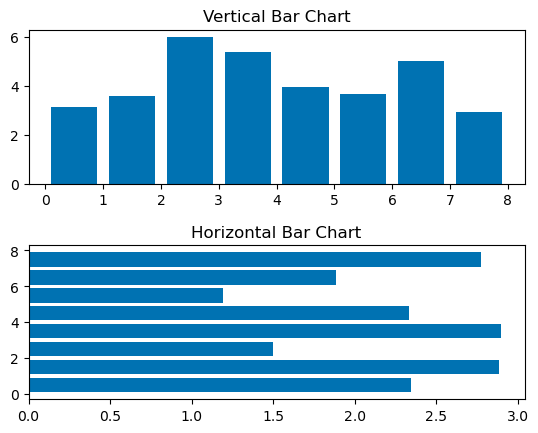

In [13]:
rng = np.random.default_rng(12345)
x = 0.5 + np.arange(8)
v1 = rng.uniform(2, 7, size=len(x))
v2 = rng.uniform(1, 3, size=len(x))

### Your code goes here

fig, (ax11, ax21) = plt.subplots(2, 1)
fig.subplots_adjust(hspace=0.4)
ax11.bar(x, v1)
ax11.set_title('Vertical Bar Chart')
ax21.barh(x, v2)
ax21.set_title('Horizontal Bar Chart')
plt.show()

### Exercise
In the below cell we have generated a randomly generated vector v3. Create the following plot:
- A histogram. Use the hist() function
- Add the title "Normal Distribution"
- Add the labels "X-axis" to the X-axis and "Y-axis" to the Y-axis
- Set the color of the histogram to "skyblue"

Use the scripting API

In [ ]:
v3 = rng.normal(0.0, 2.0, 1000)

fig, ax = plt.subplots()
ax.hist(v3, color = "skyblue")
### Your code goes here

## Seaborn

Seaborn is a visualization package built on top of matplotlib. This gives the Seaborn API some similarities to matplotlib. The advantages of using seaborn are:

- easy integration with Pandas dataframes,
- build more complex graphs.

We will demonstrate exampels of this below. The documentation for the lastest stable verion of Seaborn is here:

https://seaborn.pydata.org/api.html


In [ ]:
import seaborn as sns
pgn = sns.load_dataset("penguins")
pgn.head()

In [ ]:
sns.pairplot(pgn, hue="species", diag_kind="hist", height=1.5);

In [ ]:
sns.scatterplot(data=pgn, x="bill_length_mm", y="bill_depth_mm", hue="species");

In [ ]:
sns.jointplot(x=pgn["bill_length_mm"], y=pgn["bill_depth_mm"], alpha=0.4);

In [ ]:
v1 = pgn["bill_length_mm"]
v2 = pgn["bill_depth_mm"]
sns.jointplot(x=v1, y=v2, kind='hex');

In [ ]:
plt.figure(figsize=(7,6))
plt.subplots_adjust(bottom=0.2, left=0.2)
ax = sns.heatmap(pgn.corr(numeric_only=True), annot=True);
ax.set_xticklabels(ax.get_xticklabels(), fontsize = 8);
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize = 8);

### Exercise
Using the pgn dataframe create a Seaborn [violin plot](https://seaborn.pydata.org/generated/seaborn.violinplot.html) of the flipper length in mm. Give the plot the title "Flipper Length for 3 Penquin Species." 

In [ ]:
### Your code goes here
ax = sns.violinplot(data=pgn, x="species", y="flipper_length_mm")
ax.set_title("Flipper Length for 3 Penguin Species");

## Pandas plot

Pandas is a library for manipulating data using Series and Dataframes, see https://pandas.pydata.org/docs/index.html for more details. This is the main topic of the *Python for Data Analysis* tutorial. We previously saw a Dataframe object when we loaded the penquin dataset. 

Pandas has useful plotting tools for exploratory data analysis when you are working with a Dataframe object. To explore the pandas plotting functionality, we use the iris flower data set (https://en.wikipedia.org/wiki/Iris_flower_data_set). This is a dataset of observations on 3 species of iris flowers.

In [8]:
import pandas as pd
columns=['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'SpeciesName']
iris = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/iris-data.csv')
iris.columns=columns
# Print out a preview of the dataframe.
iris.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,SpeciesName
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### DataFrame.plot()

kind : str
   - 'line' : line plot (default)
   - 'bar' : vertical bar plot
   - 'barh' : horizontal bar plot
   - 'hist' : histogram
   - 'box' : boxplot
   - 'kde' : Kernel Density Estimation plot
   - 'density' : same as 'kde'
   - 'area' : area plot
   - 'pie' : pie plot
   - 'scatter' : scatter plot
   - 'hexbin' : hexbin plot

In [6]:
# Pandas dataframes have the matplotlib plot function built-in. 
iris.plot?

Signature:      iris.plot(*args, **kwargs)
Type:           PlotAccessor
String form:    <pandas.plotting._core.PlotAccessor object at 0x1b33e45e0>
File:           ~/miniconda3/envs/cleanlab/lib/python3.9/site-packages/pandas/plotting/_core.py
Docstring:     
Make plots of Series or DataFrame.

Uses the backend specified by the
option ``plotting.backend``. By default, matplotlib is used.

Parameters
----------
data : Series or DataFrame
    The object for which the method is called.
x : label or position, default None
    Only used if data is a DataFrame.
y : label, position or list of label, positions, default None
    Allows plotting of one column versus another. Only used if data is a
    DataFrame.
kind : str
    The kind of plot to produce:

    - 'line' : line plot (default)
    - 'bar' : vertical bar plot
    - 'barh' : horizontal bar plot
    - 'hist' : histogram
    - 'box' : boxplot
    - 'kde' : Kernel Density Estimation plot
    - 'density' : same as 'kde'
    - 'area' : are

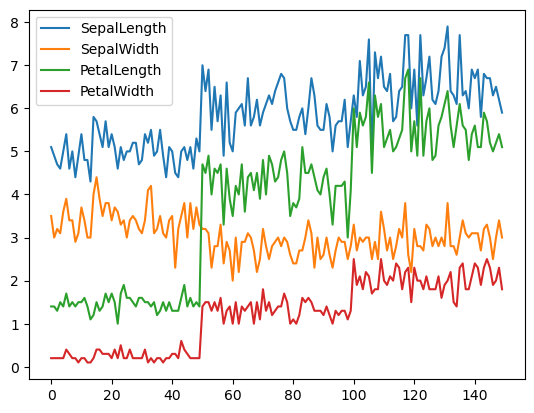

In [7]:
# Auto-plot the numeric data.  The Names column is ignored as it's all strings
# and the default is a numeric line plot.
iris.plot();

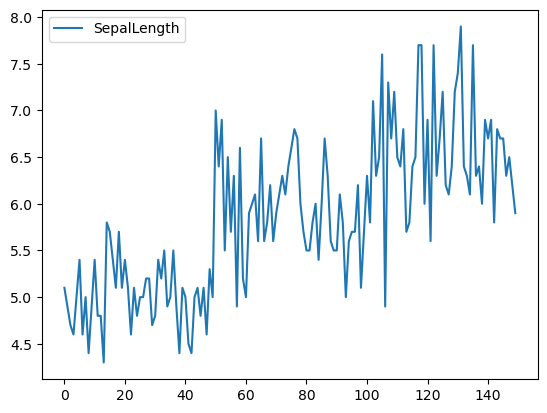

In [9]:
#Select a column with the y argument. 
#The x-values are automatically numbered by the number of rows.
iris.plot(y='SepalLength');

NameError: name 'plt' is not defined

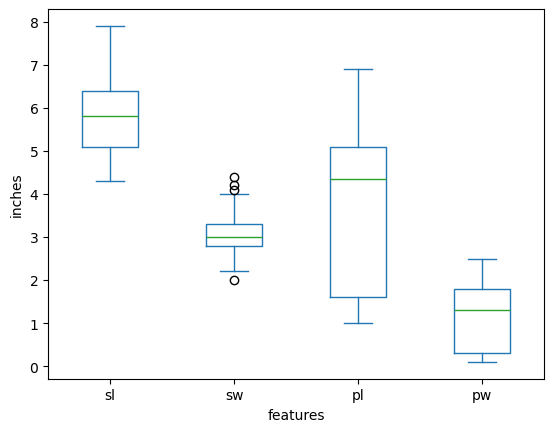

In [10]:
# Let's try some other plots...
fig=iris.plot(kind='box')
fig.set_xticklabels(['sl','sw','pl','pw']);
fig.set_xlabel('features')
fig.set_ylabel('inches')
plt.tight_layout()

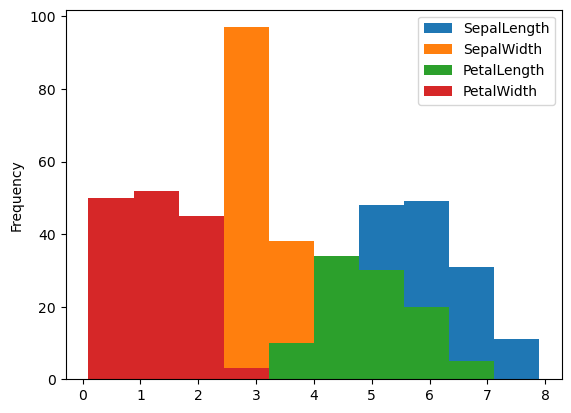

In [11]:
iris.plot(kind='hist');

In [ ]:
iris.plot(y=['SepalWidth','SepalLength'], kind='kde');

### Plot results from data manipulation

In [17]:
iris.head(10)
iris.groupby('SpeciesName').std()

,SepalLength,SepalWidth,PetalLength,PetalWidth
SpeciesName,,,,
Iris-setosa,0.352490,0.381024,0.173511,0.107210
Iris-versicolor,0.516171,0.313798,0.469911,0.197753
Iris-virginica,0.635880,0.322497,0.551895,0.274650


In [20]:
fig, ax = plt.subplots()
iris.groupby('SpeciesName').mean().plot(kind='bar', ax=ax, rot=0);
ax.set_ylabel('cm')
ax.set_xlabel('Species')
plt.show()

AttributeError: module 'matplotlib' has no attribute 'subplots'

In [ ]:
pd.plotting.scatter_matrix(iris);

## Plotly

Plotly is a great data visualization software package, see https://plotly.com/python/ for more details. A major advantage of using plotly is you can easily create interactive exportable figures easily. There are two main ways to use plotly

1. <em>plotly.express</em> 
    - Higher level interface that allows you to quickly create plots with only a few lines of code. We will demonstrate this by creating scatter plots and a chloropleth map plot. 
    
2. <em> plotly.graph_objs </em>
    - This interface requires more programming but allows for fine-tuned control of plotly plots. Functions in plotly.express wrap around graph_objs. We use graph_objs to create a 3-D visualization and to make an interactive bubble chart of colors used by painters over time.

### Plotly scatter plots

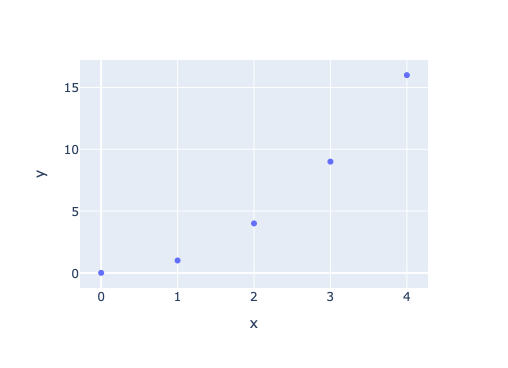

In [21]:
import plotly.express as px
fig = px.scatter(x=[0, 1, 2, 3, 4], y=[0, 1, 4, 9, 16])
fig.show()

In [ ]:
df = px.data.iris() # iris is a pandas DataFrame
fig = px.scatter(df, x="sepal_width", y="sepal_length")
fig.show()

In [ ]:
fig = px.scatter(df, x="sepal_width", y="sepal_length", color="species",
                 size='petal_length', hover_data=['petal_width'])
fig.show()

In [ ]:
fig = px.scatter(df, x="sepal_width", y="sepal_length", color='petal_length')
fig.show()

In [ ]:
fig = px.scatter(df, x="sepal_width", y="sepal_length", color="species", symbol="species")
fig.show()

To save a static figure using plotly you have to install the Python package kaleido. See this link https://plotly.com/python/static-image-export/ for more details.

In [ ]:
fig.write_image('scatter.png')

To save an interative figure using plotly you have to save as an html file and load in your browser. See this link https://plotly.com/python/interactive-html-export/ for more details.

In [ ]:
fig.write_html("scatter.html")

### Plotly chloropleth map

A map composed of colored polygons. It is used to represent spatial variations of a quantity.

In [ ]:
from urllib.request import urlopen
import json
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties = json.load(response)

import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/fips-unemp-16.csv",
                   dtype={"fips": str})

import plotly.express as px

fig = px.choropleth_mapbox(df, 
                           geojson=counties,
                           locations='fips', 
                           color='unemp',
                           color_continuous_scale="Viridis",
                           range_color=(0, 12),
                           mapbox_style="carto-positron",
                           zoom=3, 
                           center = {"lat": 37.0902, "lon": -95.7129},
                           opacity=0.5,
                           labels={'unemp':'unemployment rate'}
                          )
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

### Plotly animations

In [ ]:
import plotly.express as px
df = px.data.gapminder()
fig1 = px.scatter(df, 
                  x="gdpPercap", 
                  y="lifeExp", 
                  animation_frame="year", 
                  animation_group="country",
                  size="pop", 
                  color="continent", 
                  hover_name="country",
                  log_x=True, 
                  size_max=55, 
                  range_x=[100,100000], 
                  range_y=[25,90])
fig1.show()

In [ ]:
fig1.write_html("animation.html")

### Plotly 3-D elevation maps

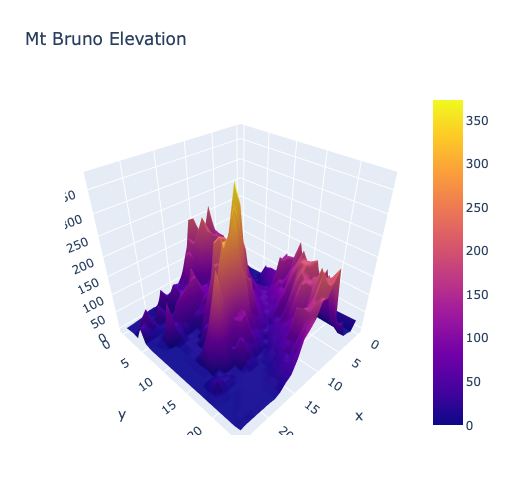

In [22]:
import plotly.graph_objects as go

import pandas as pd

# Read data from a csv
z_data = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/api_docs/mt_bruno_elevation.csv')

fig = go.Figure(data=[go.Surface(z=z_data.values)])

fig.update_layout(title='Mt Bruno Elevation', 
                  autosize=False,
                  width=500, 
                  height=500,
                  margin=dict(l=65, r=50, b=65, t=90))

fig.show()

### Plotly bubble charts

A type of scatter plot in which a third dimension of the data is shown through the size of the markers.

In [ ]:
df = pd.read_csv("bubblechart_test4.csv")
df.head()

In [ ]:
columns = df.columns

for c in [3, 6, 9, 12, 15]:
    df[columns[c]] = df[columns[c]].str.slice(0, 7)

In [ ]:
df.head()

In [ ]:
trace1 = {
    "uid": "12a671",
    "mode": "markers",
    "name": "trace_0",
    "type": "scatter",
    "x": df[columns[0]],
    "y": df["trace_0, y"],
    "marker": {
        "cmax": 1,
        "cmin": 0,
        "line": {"width": 0},
        "sizeref": 0.05,
        "size": df["trace_0, size"],
        "color": df["trace_0, color"]
    },
    "text": df[columns[2]]
}
trace2 = {
    "uid": "98e6f5",
    "mode": "markers",
    "name": "trace_1",
    "type": "scatter",
    "x": df[columns[0]],
    "y": df["trace 1, y"],
    "marker": {
        "cmax": 1,
        "cmin": 0,
        "line": {"width": 0},
        "sizeref": 0.05,
        "size": df["trace 1, size"],
        "color": df["trace 1, color"]
    },
    "text": df[columns[2]]
}
trace3 = {
    "uid": "027e97",
    "mode": "markers",
    "name": "trace_2",
    "type": "scatter",
    "x": df[columns[0]],
    "y": df["trace 2, y"],
    "marker": {
        "cmax": 1,
        "cmin": 0,
        "line": {"width": 0},
        "sizeref": 0.05,
        "size": df["trace 2, size"],
        "color": df["trace 2, color"]
    },
    "text": df[columns[2]]
}
trace4 = {
    "uid": "e4a0f1",
    "mode": "markers",
    "name": "trace_3",
    "type": "scatter",
    "x": df[columns[0]],
    "y": df["Trace 3, y"],
    "marker": {
        "cmax": 1,
        "cmin": 0,
        "line": {"width": 0},
        "sizeref": 0.05,
        "size": df["Trace 3, size"],
        "color": df["Trace 3, color"]
    },
    "text": df[columns[2]]
}
trace5 = {
    "uid": "37cb9c",
    "mode": "markers",
    "name": "trace_4",
    "type": "scatter",
    "x": df[columns[0]],
    "y": df["Trace 4, y"],
    "marker": {
        "cmax": 1,
        "cmin": 0,
        "line": {"width": 0},
        "sizeref": 0.05,
        "size": df["Trace 4, size"],
        "color": df["Trace 4, color"]
    },
    "text": df[columns[2]]
}

In [ ]:
data = [trace1, trace2, trace3, trace4, trace5]
layout = {
  "title": "Master Painter Color Choices Throughout History", 
  "width": 922, 
  "xaxis": {
    "type": "linear", 
    "range": [939.9038345713712, 1993.1802850833167], 
    "title": "Year", 
    "autorange": True
  }, 
  "yaxis": {
    "type": "linear", 
    "range": [-35.062697972997384, 391.630565826398], 
    "title": "Hue Value", 
    "autorange": True
  }, 
  "height": 567, 
  "autosize": True, 
  "hovermode": "closest", 
  "showlegend": False
}
fig = go.Figure(data=data, layout=layout)
fig.show()

## Please fill an evaluation
http://scv.bu.edu/eval
    
## Future questions for SCC
help@scc.bu.edu